## Importação de bibliotecas

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

## Questão 1 (a)

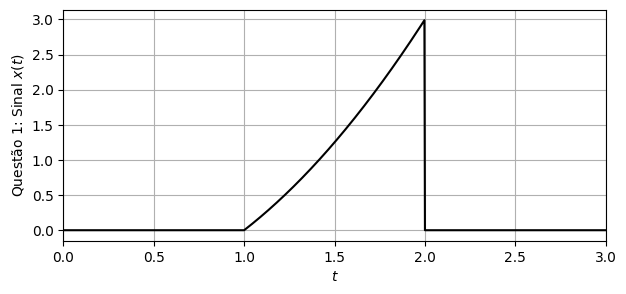

In [7]:
t_inicio = 0
t_fim = 3
npoints = 1000
t = np.linspace(t_inicio, t_fim, npoints)


u1 = 1.0 * (t >= 1)
u2 = 1.0 * (t >= 2)
x = (t**2 - 1) * (u1 - u2)

plt.figure(figsize=(7,3))
plt.plot(t,x, 'k')
plt.xlabel('$t$')
plt.ylabel('Questão 1: Sinal $x(t)$')
plt.xlim([t_inicio, t_fim])
plt.grid()
plt.show()

## Questão 1 (b)

Considere o sinal de tempo contínuo definido pela expressão:
$x(t) = (t^2 - 1)[u(t-1) - u(t-2)]$

**(b) Cálculo Analítico da Energia:**
A energia de um sinal contínuo $x(t)$ é dada por $E_x = \int_{-\infty}^{\infty} |x(t)|^2 dt$.
Devido aos degraus unitários, o sinal é não-nulo apenas no intervalo $1 \le t \le 2$:

$$E_x = \int_{1}^{2} (t^2 - 1)^2 dt = \int_{1}^{2} (t^4 - 2t^2 + 1) dt$$

Resolvendo a integral:
$$E_x = \left[ \frac{t^5}{5} - \frac{2t^3}{3} + t \right]_{1}^{2}$$
$$E_x = \left( \frac{32}{5} - \frac{16}{3} + 2 \right) - \left( \frac{1}{5} - \frac{2}{3} + 1 \right) = \frac{31}{5} - \frac{14}{3} + 1 = \frac{93 - 70 + 15}{15} = \frac{38}{15} \approx 2.5333$$

## Questão 1 (c)

**(c) Determinação Numérica da Energia e Comparação**

Para determinar a energia de forma numérica, aproximamos a integral contínua $E_x = \int_{-\infty}^{\infty} |x(t)|^2 dt$ através de uma soma de Riemann baseada nos pontos amostrados no vetor de tempo:

$$E_{num} \approx \sum_{i} |x(t_i)|^2 \cdot \Delta t$$

Onde:
* $x(t_i)$ são os valores do sinal no instante $i$.
* $\Delta t$ é o intervalo entre as amostras (passo de integração).

In [8]:
dt = (t_fim - t_inicio) / npoints
Ex_num = np.sum(x**2) * dt

print(f'Energia (computacional) = {Ex_num:.4f}')
print(f'Energia (analítica) = 2.5333')

Energia (computacional) = 2.5173
Energia (analítica) = 2.5333


## Questão 2 (a)

**(a) Expressão matemática para $x(t)$:**
Analisando a Figura 1, o sinal é composto por uma constante e um decaimento exponencial:
- Parte constante: x = $2$, no intervalo $-1.5 \le t < 0$.
- Parte exponencial: x = $2e^{-t/2}$, no intervalo $0 \le t \le 3$.

A expressão matemática utilizando a função degrau $u(t)$ é:
$$x(t) = 2[u(t+1.5) - u(t)] + 2e^{-t/2}[u(t) - u(t-3)]$$


## Questão 2 (b)

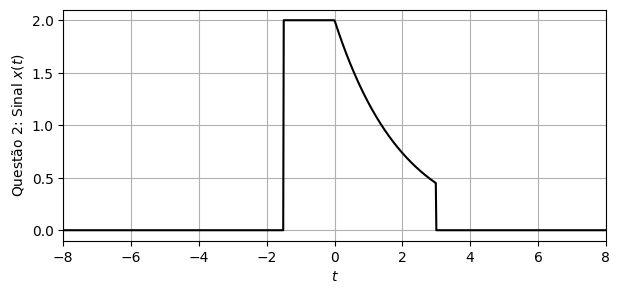

In [9]:
def sinal(t):
    return 2*(np.logical_and(t >= -1.5, t < 0)) + (2*np.exp(-t/2))*(np.logical_and(t >= 0, t <= 3))

t_inicio =-8
t_fim = 8
npoints = 1000
t = np.linspace(t_inicio, t_fim, npoints)
x1 = sinal(t)


plt.figure(figsize=(7,3))
plt.plot(t,x1, 'k')
plt.xlabel('$t$')
plt.ylabel('Questão 2: Sinal $x(t)$')
plt.xlim([t_inicio, t_fim])
plt.grid()
plt.show()


## Questão 2 (c)

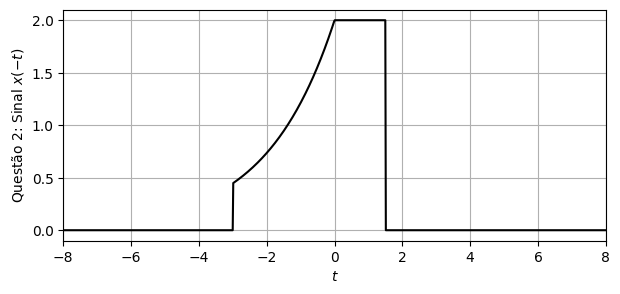

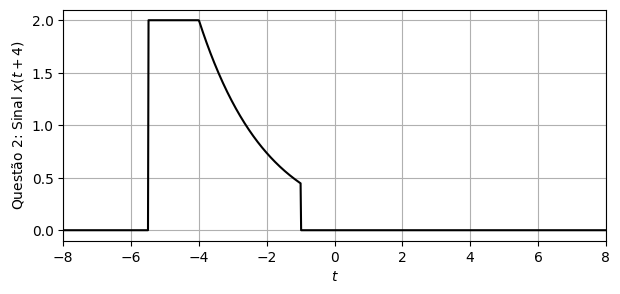

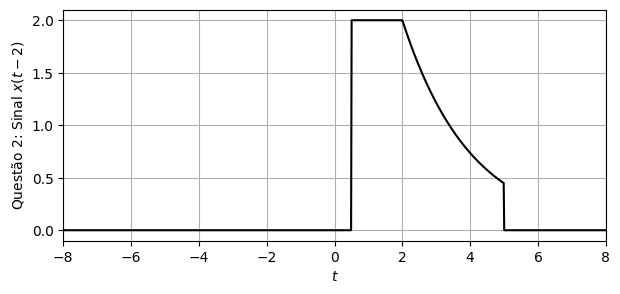

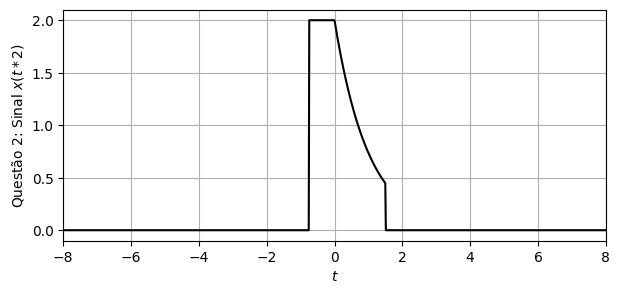

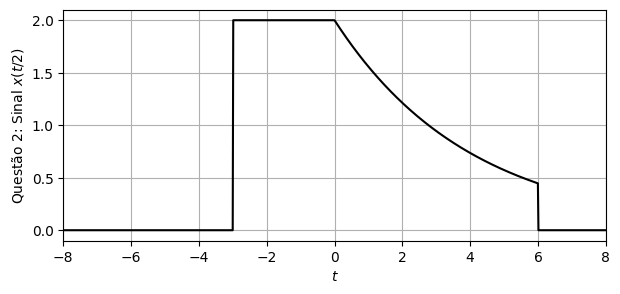

In [10]:
def sinal(t):
    return 2*(np.logical_and(t >= -1.5, t < 0)) + (2*np.exp(-t/2))*(np.logical_and(t >= 0, t <= 3))

t_inicio =-8
t_fim = 8
npoints = 1000
t = np.linspace(t_inicio, t_fim, npoints)
x2 = sinal(-t)
x3 = sinal(t+4)
x4 = sinal(t-2)
x5 = sinal(t*2)
x6 = sinal(t/2)

plt.figure(figsize=(7,3))
plt.plot(t,x2, 'k')
plt.xlabel('$t$')
plt.ylabel('Questão 2: Sinal $x(-t)$')
plt.xlim([t_inicio, t_fim])
plt.grid()
plt.show()

plt.figure(figsize=(7,3))
plt.plot(t,x3, 'k')
plt.xlabel('$t$')
plt.ylabel('Questão 2: Sinal $x(t + 4)$')
plt.xlim([t_inicio, t_fim])
plt.grid()
plt.show()

plt.figure(figsize=(7,3))
plt.plot(t,x4, 'k')
plt.xlabel('$t$')
plt.ylabel('Questão 2: Sinal $x(t - 2)$')
plt.xlim([t_inicio, t_fim])
plt.grid()
plt.show()

plt.figure(figsize=(7,3))
plt.plot(t,x5, 'k')
plt.xlabel('$t$')
plt.ylabel('Questão 2: Sinal $x(t * 2)$')
plt.xlim([t_inicio, t_fim])
plt.grid()
plt.show()

plt.figure(figsize=(7,3))
plt.plot(t,x6, 'k')
plt.xlabel('$t$')
plt.ylabel('Questão 2: Sinal $x(t / 2)$')
plt.xlim([t_inicio, t_fim])
plt.grid()
plt.show()

**(c) Comentários sobre as operações:**
* **$x(-t)$**: Reversão no tempo (espelhamento no eixo vertical).
* **$x(t+4)$**: Deslocamento à esquerda (adiantamento de 4 unidades).
* **$x(t-2)$**: Deslocamento à direita (atraso de 2 unidades).
* **$x(2t)$**: Compressão temporal por um fator de 2.
* **$x(t/2)$**: Expansão temporal por um fator de 2.

## Questão 3

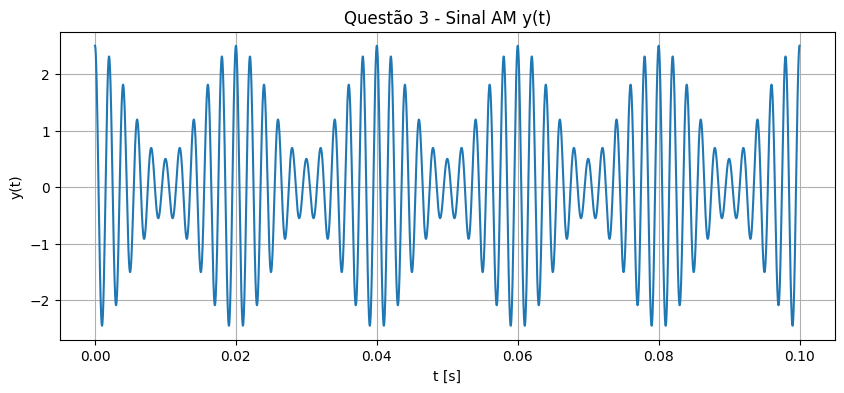

In [11]:
fm = 50
fc = 500
A = 1.5

t = np.linspace(0, 0.1, 5000)

x = np.cos(2 * np.pi * fm * t)
y = (A + x) * np.cos(2 * np.pi * fc * t)

plt.figure(figsize=(10, 4))
plt.plot(t, y)
plt.title("Questão 3 - Sinal AM y(t)")
plt.xlabel("t [s]")
plt.ylabel("y(t)")
plt.grid(True)
plt.show()

## Questão 4 (a)

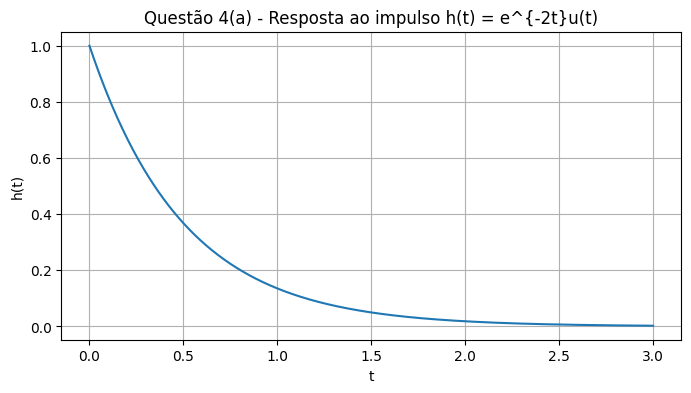

In [12]:
t = np.linspace(0, 3, 1000)
h = np.exp(-2*t)

plt.figure(figsize=(8, 4))
plt.plot(t, h)
plt.title("Questão 4(a) - Resposta ao impulso h(t) = e^{-2t}u(t)")
plt.xlabel("t")
plt.ylabel("h(t)")
plt.grid(True)
plt.show()

## Questão 4 (b) 

A resposta ao impulso do sistema é dada por:

$$
h(t) = e^{-2t}u(t)
$$

O sistema é causal, pois sua resposta ao impulso é nula para valores de tempo negativos. Como existe o degrau unitário \(u(t)\), tem-se:

$$
h(t) = 0, \quad t < 0
$$

Logo, o sistema não responde antes da aplicação da entrada, caracterizando um sistema causal.

Para verificar a estabilidade, utiliza-se a condição de estabilidade BIBO para sistemas lineares e invariantes no tempo. Um sistema LIT é estável se:

$$
\int_{-\infty}^{\infty} |h(t)| \, dt < \infty
$$

Substituindo \(h(t)\):

$$
\int_{-\infty}^{\infty} |h(t)| \, dt
=
\int_0^{\infty} e^{-2t} \, dt
$$

Calculando a integral:

$$
\int_0^{\infty} e^{-2t} \, dt
=
\left[-\frac{1}{2}e^{-2t}\right]_0^{\infty}
$$

$$
=
0 - \left(-\frac{1}{2}\right)
=
\frac{1}{2}
$$

Como o resultado é finito, conclui-se que o sistema é **estável**.

Portanto, o sistema é **causal e estável**.

## Questão 4 (c)

Considere que o seguinte sinal:

$$
x(t) = u(t) - u(t-2)
$$

é aplicado na entrada do sistema. A resposta ao impulso é:

$$
h(t) = e^{-2t}u(t)
$$

A saída do sistema é obtida pela convolução:

$$
y(t) = x(t) * h(t)
$$

Como:

$$
x(t) = u(t) - u(t-2)
$$

podemos escrever:

$$
y(t) = [u(t) - u(t-2)] * h(t)
$$

Pela propriedade da linearidade da convolução:

$$
y(t) = u(t)*h(t) - u(t-2)*h(t)
$$

Primeiro, calcula-se a resposta do sistema à entrada \(u(t)\):

$$
s(t) = u(t)*h(t)
$$

$$
s(t) = \int_{-\infty}^{\infty} u(\tau)e^{-2(t-\tau)}u(t-\tau)\,d\tau
$$

Como a integração ocorre no intervalo \(0 \leq \tau \leq t\), temos:

$$
s(t) = \int_0^t e^{-2(t-\tau)}\,d\tau
$$

$$
s(t) = e^{-2t}\int_0^t e^{2\tau}\,d\tau
$$

$$
s(t) = e^{-2t}\left[\frac{e^{2\tau}}{2}\right]_0^t
$$

$$
s(t) = e^{-2t}\left(\frac{e^{2t}-1}{2}\right)
$$

$$
s(t) = \frac{1-e^{-2t}}{2}
$$

Considerando a presença da função degrau, a resposta ao degrau pode ser escrita como:

$$
s(t) = u(t)\frac{1-e^{-2t}}{2}
$$

Como o sinal de entrada é a diferença entre dois degraus, temos:

$$
y(t) = s(t) - s(t-2)
$$

Logo:

$$
y(t) = u(t)\frac{1-e^{-2t}}{2} - u(t-2)\frac{1-e^{-2(t-2)}}{2}
$$

Portanto, a saída do sistema é:

$$
\boxed{
y(t) = u(t)\frac{1-e^{-2t}}{2} - u(t-2)\frac{1-e^{-2(t-2)}}{2}
}
$$

## Questão 4 (d)

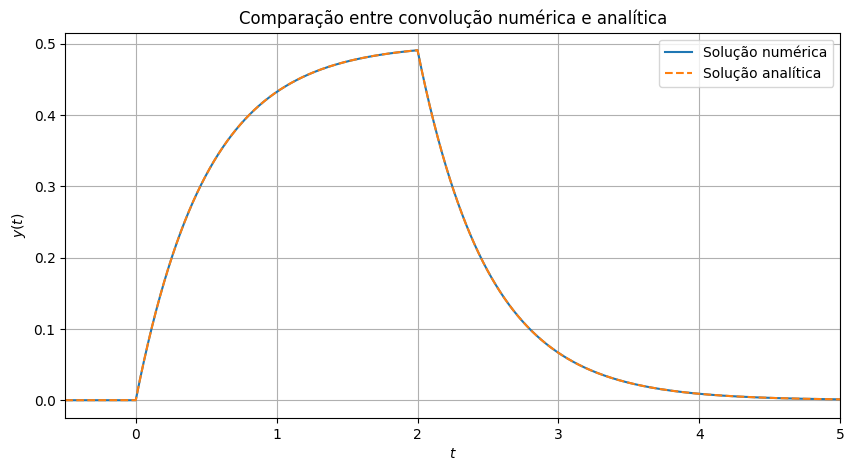

In [13]:
def u(t):
    return 1.0*(t >= 0)

t_inicio = -1
t_fim = 6
npoints = 10000

t = np.linspace(t_inicio, t_fim, npoints)
dt = t[1] - t[0]

x = u(t) - u(t - 2)
h = np.exp(-2*t) * u(t)

y_num = dt * np.convolve(x, h, mode='full')

t_y = np.linspace(2*t_inicio, 2*t_fim, len(y_num))

y_ana = np.zeros_like(t_y)

cond1 = (t_y >= 0) & (t_y < 2)
cond2 = (t_y >= 2)

y_ana[cond1] = (1 - np.exp(-2*t_y[cond1])) / 2
y_ana[cond2] = (np.exp(-2*(t_y[cond2]-2)) - np.exp(-2*t_y[cond2])) / 2

plt.figure(figsize=(10,5))
plt.plot(t_y, y_num, label='Solução numérica')
plt.plot(t_y, y_ana, '--', label='Solução analítica')
plt.xlabel('$t$')
plt.ylabel('$y(t)$')
plt.title('Comparação entre convolução numérica e analítica')
plt.grid()
plt.xlim([-0.5, 5])
plt.legend()
plt.show()

## Questão 4 (e)

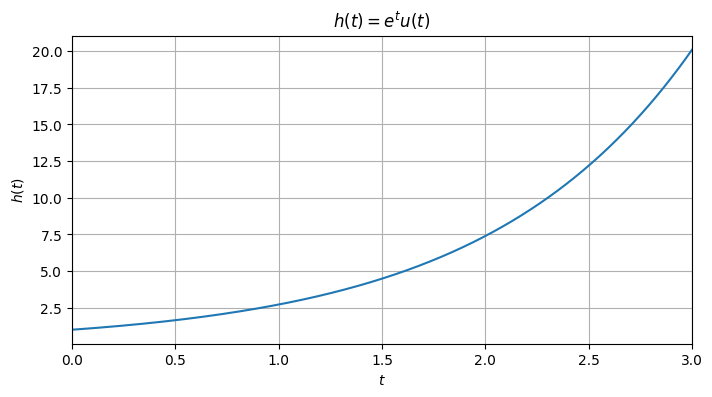

In [14]:
t_inicio = 0
t_fim = 3
npoints = 1000

t = np.linspace(t_inicio, t_fim, npoints)

h = np.exp(t) * (t >= 0)

plt.figure(figsize=(8,4))
plt.plot(t, h)
plt.xlabel('$t$')
plt.ylabel('$h(t)$')
plt.title('$h(t)=e^tu(t)$')
plt.grid()
plt.xlim([t_inicio, t_fim])
plt.show()

O sistema é causal, pois h(t) = e^t u(t) é nula para t < 0.

Entretanto, o sistema não é estável BIBO, pois:

$$
\int_0^{\infty} |e^t|dt
$$

diverge. Portanto, a resposta ao impulso não é absolutamente integrável e o sistema é instável.

Agora, considere a resposta ao impulso:

$$
h(t) = e^{t}u(t)
$$

e a mesma entrada:

$$
x(t) = u(t) - u(t-2)
$$

A saída do sistema é obtida pela convolução:

$$
y(t) = x(t) * h(t)
$$

Substituindo \(x(t)\), temos:

$$
y(t) = [u(t) - u(t-2)] * h(t)
$$

Pela propriedade da linearidade:

$$
y(t) = u(t)*h(t) - u(t-2)*h(t)
$$

Primeiro, calcula-se a resposta do sistema à entrada \(u(t)\):

$$
s(t) = u(t)*h(t)
$$

$$
s(t) = \int_{-\infty}^{\infty} u(\tau)e^{t-\tau}u(t-\tau)\,d\tau
$$

Como a integração ocorre no intervalo \(0 \leq \tau \leq t\), temos:

$$
s(t) = \int_0^t e^{t-\tau}\,d\tau
$$

$$
s(t) = e^t\int_0^t e^{-\tau}\,d\tau
$$

$$
s(t) = e^t\left[-e^{-\tau}\right]_0^t
$$

$$
s(t) = e^t(-e^{-t} + 1)
$$

$$
s(t) = e^t - 1
$$

Considerando a função degrau, a resposta ao degrau é:

$$
s(t) = u(t)(e^t - 1)
$$

Como a entrada é composta pela diferença entre dois degraus, temos:

$$
y(t) = s(t) - s(t-2)
$$

Logo:

$$
y(t) = u(t)(e^t - 1) - u(t-2)(e^{t-2} - 1)
$$

Portanto, a saída do sistema é:

$$
\boxed{
y(t) = u(t)(e^t - 1) - u(t-2)(e^{t-2} - 1)
}
$$

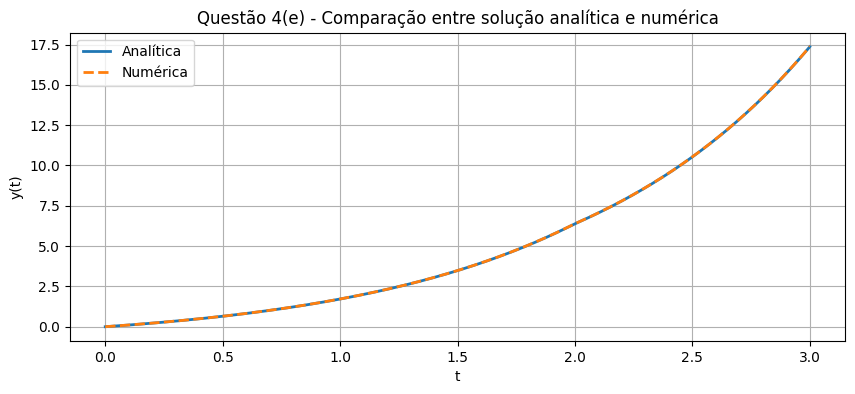

In [15]:
dt = 0.001

t = np.arange(0, 3, dt)

x = np.where((t >= 0) & (t < 2), 1, 0)
h = np.exp(t)

y_num = np.convolve(x, h, mode="full") * dt
t_conv = np.arange(0, len(y_num)) * dt

def y_analitica_instavel(t):
    return np.where(
        t < 0,
        0,
        np.where(
            t < 2,
            np.exp(t) - 1,
            np.exp(t) * (1 - np.exp(-2))
        )
    )

y_an = y_analitica_instavel(t_conv)

mascara = (t_conv >= 0) & (t_conv <= 3)

plt.figure(figsize=(10, 4))
plt.plot(t_conv[mascara], y_an[mascara], label="Analítica", linewidth=2)
plt.plot(t_conv[mascara], y_num[mascara], "--", label="Numérica", linewidth=2)
plt.title("Questão 4(e) - Comparação entre solução analítica e numérica")
plt.xlabel("t")
plt.ylabel("y(t)")
plt.legend()
plt.grid(True)
plt.show()

## Questão 5 (a)

Resolução da Equação Diferencial - Método Clássico

**Circuito Elétrico:** Tensão de entrada $v_i(t)$ e saída $v_o(t)$.

**Equação Diferencial:**
$$\frac{d^2v_o(t)}{dt^2} + 7\frac{dv_o(t)}{dt} + 10v_o(t) = \frac{dv_i(t)}{dt} + 6v_i(t)$$

**Dados do Problema:**
*   Entrada: $v_i(t) = 6e^{-3t}u(t)$
*   Condições Iniciais: $v_o(0) = 6\text{V}$ e $v_o'(0) = -4\text{V/s}$

---

1. Resposta Natural ($v_n(t)$)
A resposta natural é obtida resolvendo a equação homogênea associada:
$$\frac{d^2v_o(t)}{dt^2} + 7\frac{dv_o(t)}{dt} + 10v_o(t) = 0$$

Assumindo a solução da forma $e^{\lambda t}$, obtemos a equação característica:
$$\lambda^2 + 7\lambda + 10 = 0$$

Fatorando o polinômio:
$$(\lambda + 2)(\lambda + 5) = 0 \implies \lambda_1 = -2, \lambda_2 = -5$$

Como as raízes são reais e distintas, a resposta natural é:
$$v_n(t) = C_1 e^{-2t} + C_2 e^{-5t}$$

---

2. Resposta Forçada ($v_f(t)$)
Primeiro, avaliamos o termo de excitação $f(t)$ resultante da entrada $v_i(t) = 6e^{-3t}$ para $t > 0$:
$$f(t) = \frac{dv_i(t)}{dt} + 6v_i(t) = \frac{d}{dt}(6e^{-3t}) + 6(6e^{-3t})$$
$$f(t) = -18e^{-3t} + 36e^{-3t} = 18e^{-3t}$$

Para uma excitação de forma $e^{-3t}$, a solução forçada é do tipo:
$$v_f(t) = Ke^{-3t}$$

Substituindo $v_f(t)$ na EDO:
$$\frac{d^2}{dt^2}(Ke^{-3t}) + 7\frac{d}{dt}(Ke^{-3t}) + 10(Ke^{-3t}) = 18e^{-3t}$$
$$9Ke^{-3t} - 21Ke^{-3t} + 10Ke^{-3t} = 18e^{-3t}$$
$$-2K = 18 \implies K = -9$$

Portanto:
$$v_f(t) = -9e^{-3t}$$

---

3. Solução Geral e Cálculo das Constantes
A solução completa é a soma das respostas:
$$v_o(t) = v_n(t) + v_f(t) = C_1 e^{-2t} + C_2 e^{-5t} - 9e^{-3t}$$

Aplicamos as condições iniciais em $t = 0$:

**I. Para $v_o(0) = 6$:**
$$C_1 + C_2 - 9 = 6 \implies C_1 + C_2 = 15$$

**II. Para $v_o'(0) = -4$:**
Derivada da solução geral: $v_o'(t) = -2C_1 e^{-2t} - 5C_2 e^{-5t} + 27e^{-3t}$
$$-2C_1 - 5C_2 + 27 = -4 \implies -2C_1 - 5C_2 = -31$$

Resolvendo o sistema linear:
$$\begin{cases} C_1 + C_2 = 15 \\ -2C_1 - 5C_2 = -31 \end{cases}$$
Multiplicando a primeira por 2: $2C_1 + 2C_2 = 30$
Somando as equações: $-3C_2 = -1 \implies C_2 = 1/3$
Substituindo em $C_1$: $C_1 = 15 - 1/3 = 44/3$

---

4. Resposta Final
Substituindo as constantes encontradas:
$$v_o(t) = y(t) = \left( \frac{44}{3}e^{-2t} + \frac{1}{3}e^{-5t} - 9e^{-3t} \right) u(t) \text{ Volts}$$

## Questão 5 (b)

Plot do sinal de saída para $0 \leq t \leq 2$

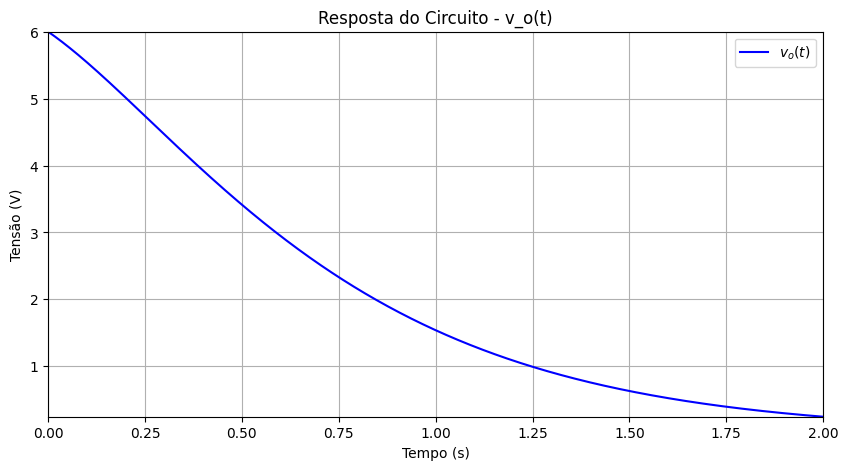

In [16]:
import numpy as np
import matplotlib.pyplot as plt

t_plot = np.linspace(0, 2, 1000)

def v_o_analitica(t):
    return (44/3)*np.exp(-2*t) + (1/3)*np.exp(-5*t) - 9*np.exp(-3*t)

y_vals = v_o_analitica(t_plot)

plt.figure(figsize=(10, 5))
plt.plot(t_plot, y_vals, label=r'$v_o(t)$', color='blue')
plt.xlim(0, 2)
plt.ylim(y_vals.min(), y_vals.max())
plt.title('Resposta do Circuito - v_o(t)')
plt.xlabel('Tempo (s)')
plt.ylabel('Tensão (V)')
plt.grid(True)
plt.legend()
plt.show()

## Questão 5 (c)

(c) Computação Simbólica e Comparação
Utilização da biblioteca `sympy` para resolver a EDO e validar os resultados obtidos manualmente.

In [17]:
import sympy as sp
from IPython.display import display

t_sym = sp.symbols('t', real=True, positive=True)
vo = sp.Function('vo')
vi = 6 * sp.exp(-3*t_sym)

edo = sp.Eq(vo(t_sym).diff(t_sym, t_sym) + 7*vo(t_sym).diff(t_sym) + 10*vo(t_sym), 
            vi.diff(t_sym) + 6*vi)

ics = {vo(0): 6, vo(t_sym).diff(t_sym).subs(t_sym, 0): -4}

sol_simbolica = sp.dsolve(edo, ics=ics)

if isinstance(sol_simbolica, list):
    sol_final = sol_simbolica[0]
else:
    sol_final = sol_simbolica

print("Expressão obtida via SymPy:")
display(sol_final)

v_simb_func = sp.lambdify(t_sym, sol_final.rhs, 'numpy')
erro_max = np.abs(y_vals - v_simb_func(t_plot)).max()
print(f"Erro máximo de comparação: {erro_max:.2e}")

Expressão obtida via SymPy:


Eq(vo(t), (44/3 - 9*exp(-t) + exp(-3*t)/3)*exp(-2*t))

Erro máximo de comparação: 2.66e-15
